# Skin Disease Classification: Exploratory Data Analysis (EDA) & Model Evaluation
### Scientific Research & Diagnostics Tool

This notebook provides a detailed walkthrough of the exploratory data analysis, preprocessing pipeline, model architectures (Custom CNN vs Fine-tuned ResNet-18), training history, and clinical evaluation metrics for classifying skin lesions into four distinct categories:
1. **Melanoma** (Malignant)
2. **Melanocytic Nevus** (Benign)
3. **Basal Cell Carcinoma (BCC)** (Malignant)
4. **Seborrheic Keratosis** (Benign)

--- 
## 1. Setup & Environment Dependencies

In [1]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

--- 
## 2. Dataset Distribution Analysis
We check the count of images in our generated dataset to ensure there are no class imbalances between our training and validation splits.

   Split                 Class  Count
0  train              melanoma    200
1  train                 nevus    200
2  train                   bcc    200
3  train  seborrheic_keratosis    200
4    val              melanoma     50
5    val                 nevus     50
6    val                   bcc     50
7    val  seborrheic_keratosis     50


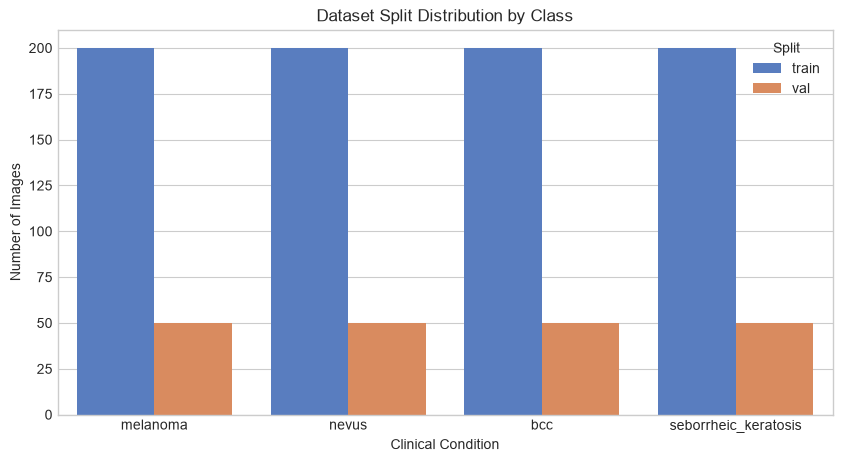

In [2]:
dataset_dir = "dataset"
classes = ["melanoma", "nevus", "bcc", "seborrheic_keratosis"]

stats = []
for split in ['train', 'val']:
    for cls in classes:
        path = os.path.join(dataset_dir, split, cls)
        if os.path.exists(path):
            count = len(os.listdir(path))
            stats.append({"Split": split, "Class": cls, "Count": count})
        else:
            stats.append({"Split": split, "Class": cls, "Count": 0})

df_stats = pd.DataFrame(stats)
print(df_stats)

# Plot the distributions
plt.figure(figsize=(10, 5))
sns.barplot(data=df_stats, x="Class", y="Count", hue="Split", palette="muted")
plt.title("Dataset Split Distribution by Class")
plt.ylabel("Number of Images")
plt.xlabel("Clinical Condition")
plt.show()

--- 
## 3. Visualizing Skin Lesion Samples
Let's display sample dermoscopy images from each category. This helps researchers understand the distinguishing features learned by the CNN.

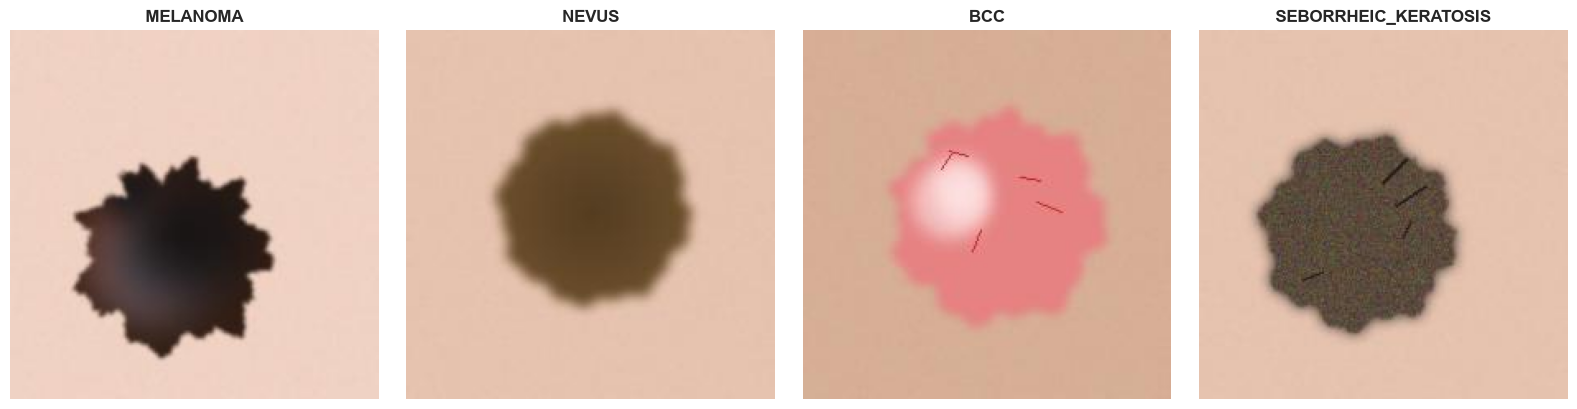

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cls in enumerate(classes):
    cls_dir = os.path.join(dataset_dir, 'train', cls)
    if os.path.exists(cls_dir) and len(os.listdir(cls_dir)) > 0:
        sample_file = os.listdir(cls_dir)[0]
        img_path = os.path.join(cls_dir, sample_file)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(cls.upper(), fontsize=12, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"No data for\n{cls}", ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

--- 
## 4. Preprocessing & Data Augmentation Pipelines
Data augmentations are key to optimizing generalizability and preventing overfitting. The training pipeline uses random horizontal and vertical flips, rotations, and color jitter to expand our effective sample size.

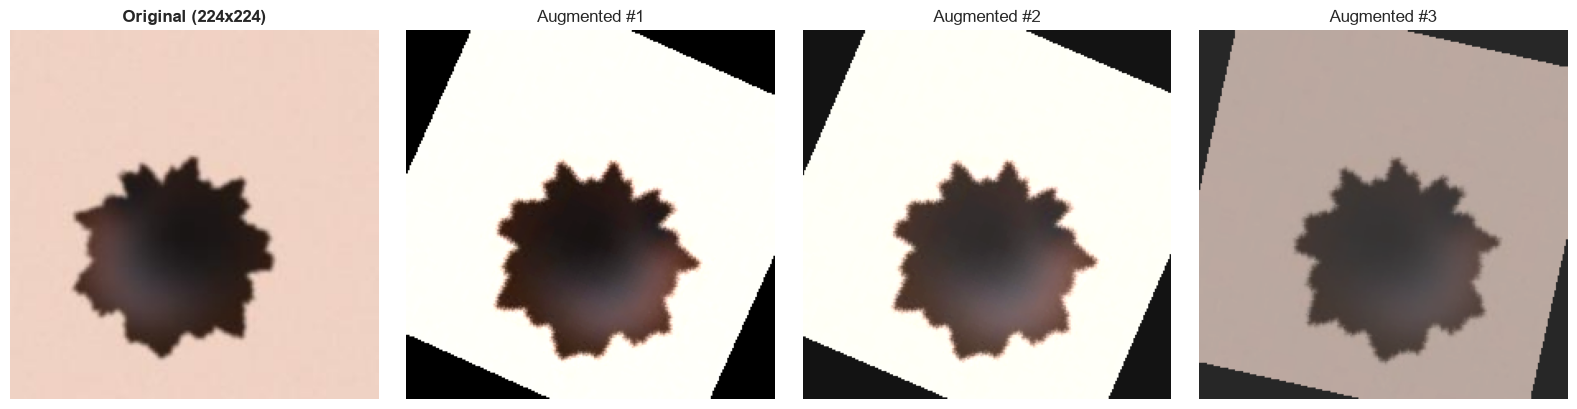

In [4]:
# Preprocess sample transforms
demo_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0), # Force flip for demo
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3)
])

# Load a sample image
sample_path = os.path.join(dataset_dir, 'train', 'melanoma', os.listdir(os.path.join(dataset_dir, 'train', 'melanoma'))[0])
img = Image.open(sample_path)

# Generate 3 augmented versions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img.resize((224, 224)))
axes[0].set_title("Original (224x224)", fontweight='bold')
axes[0].axis('off')

for i in range(1, 4):
    aug_img = demo_transform(img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

--- 
## 5. Model Training Curves & Metrics Evaluation
Once the model has been trained by running `scripts/train.py`, we load the saved model metrics to evaluate performance, checking the training and validation history.

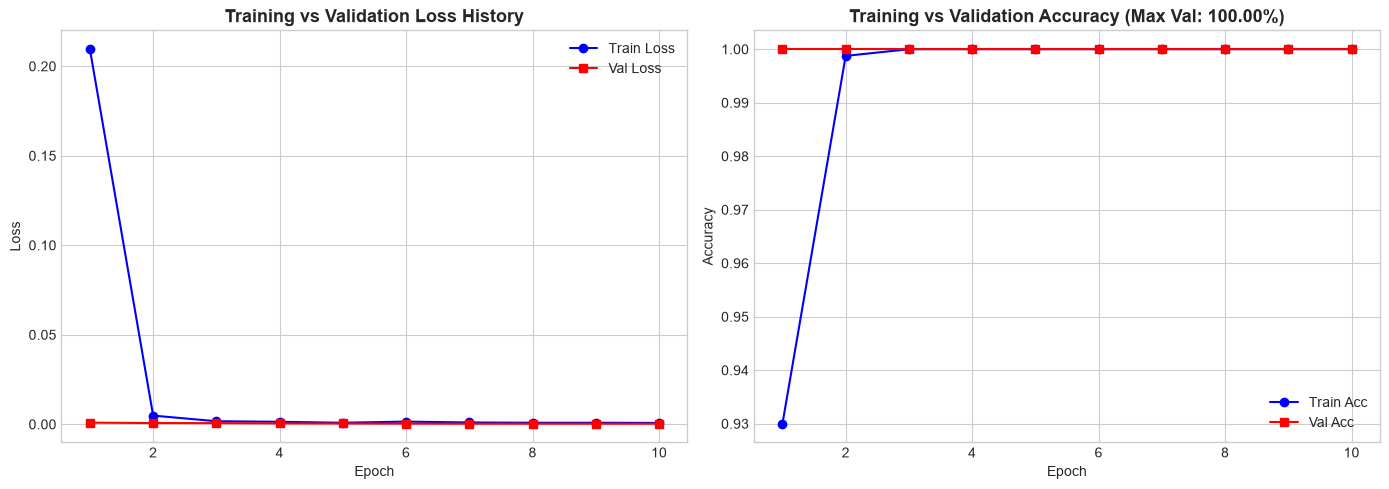

In [5]:
metrics_path = os.path.join("models", "metrics.json")

if os.path.exists(metrics_path):
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)
        
    history = metrics["history"]
    epochs = range(1, len(history["train_loss"]) + 1)
    
    # Plot loss history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history["train_loss"], 'b-o', label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], 'r-s', label="Val Loss")
    axes[0].set_title("Training vs Validation Loss History", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    
    # Plot accuracy history
    axes[1].plot(epochs, history["train_acc"], 'b-o', label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], 'r-s', label="Val Acc")
    axes[1].set_title(f"Training vs Validation Accuracy (Max Val: {max(history['val_acc'])*100:.2f}%)", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: No metrics file found. Run 'python scripts/train.py' first to train the model and save results.")

### Confusion Matrix & Classification Report
We load and visualize the confusion matrix and key metrics like precision, recall, and F1-score to assess classification characteristics.

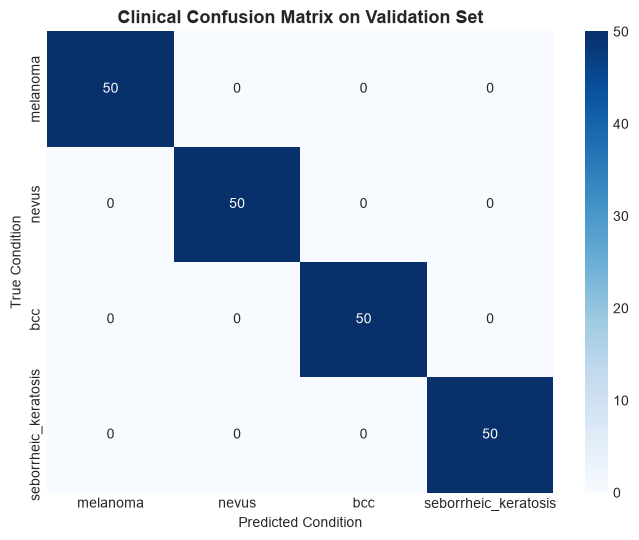


--- Classification Report Summary ---
                      precision  recall  f1-score  support
bcc                         1.0     1.0       1.0     50.0
melanoma                    1.0     1.0       1.0     50.0
nevus                       1.0     1.0       1.0     50.0
seborrheic_keratosis        1.0     1.0       1.0     50.0
accuracy                    1.0     1.0       1.0      1.0
macro avg                   1.0     1.0       1.0    200.0
weighted avg                1.0     1.0       1.0    200.0


In [6]:
if os.path.exists(metrics_path):
    cm = np.array(metrics["confusion_matrix"])
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title("Clinical Confusion Matrix on Validation Set", fontsize=13, fontweight='bold')
    plt.ylabel("True Condition")
    plt.xlabel("Predicted Condition")
    plt.tight_layout()
    plt.show()
    
    # Display precision, recall, f1-score
    print("\n--- Classification Report Summary ---")
    report_df = pd.DataFrame(metrics["class_report"]).transpose()
    print(report_df.round(3))
else:
    print("Please train the model first.")

--- 
## 6. Model Interpretation using Grad-CAM
Grad-CAM (Gradient-weighted Class Activation Mapping) produces coarse visual highlights showing where the CNN is focusing inside the image. Below, we load the trained model, pull a test image, run Grad-CAM, and visualize the attention overlay.

C:\Users\anxpr\Projects\skin-disease-classification\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\anxpr\Projects\skin-disease-classification\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


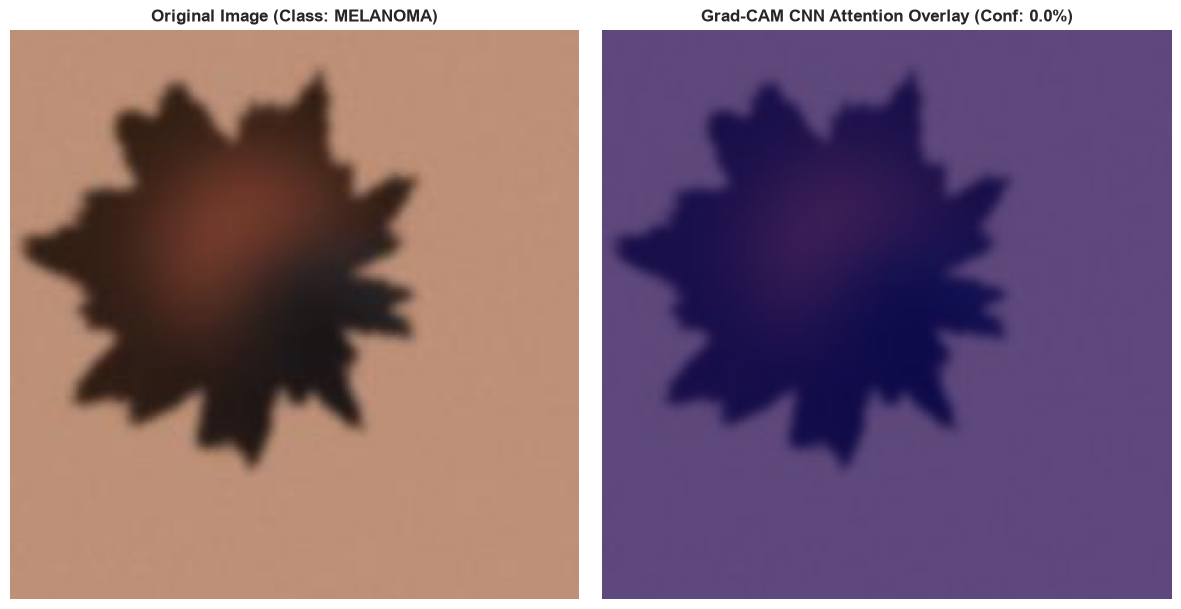

In [7]:
model_path = os.path.join("models", "skin_disease_resnet18.pth")

if os.path.exists(model_path):
    import sys
    sys.path.append(os.path.abspath('.'))
    from model.cnn_model import ResNet18Transfer, GradCAM
    
    # Initialize and load model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(model_path, map_location=device)
    model = ResNet18Transfer(num_classes=4, pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval().to(device)
    
    # Select target convolutional layer
    target_layer = model.resnet.layer4
    grad_cam = GradCAM(model, target_layer)
    
    # Preprocess a sample validation image
    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Load a sample validation image
    sample_class = "melanoma"
    sample_dir = os.path.join(dataset_dir, 'val', sample_class)
    sample_file = os.listdir(sample_dir)[0]
    img_path = os.path.join(sample_dir, sample_file)
    original_img = Image.open(img_path)
    
    # Convert to input tensor
    input_tensor = val_transforms(original_img).unsqueeze(0).to(device)
    
    # Generate attention map
    heatmap, output = grad_cam.generate_heatmap(input_tensor, class_idx=0)
    probabilities = torch.softmax(output, dim=1).squeeze().tolist()
    
    # Clean hooks
    grad_cam.remove_hooks()
    
    # Plot original side-by-side with Grad-CAM heatmap
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(original_img.resize((224, 224)))
    axes[0].set_title(f"Original Image (Class: {sample_class.upper()})", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Blend heatmap
    heatmap_resized = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((224, 224), Image.Resampling.BILINEAR)
    cmap = plt.get_cmap('jet')
    heatmap_colored = (cmap(np.array(heatmap_resized)/255.0)[:, :, :3] * 255).astype(np.uint8)
    
    original_arr = np.array(original_img.resize((224, 224)), dtype=np.float32)
    overlaid = (original_arr * 0.5 + heatmap_colored * 0.5).astype(np.uint8)
    
    axes[1].imshow(overlaid)
    axes[1].set_title(f"Grad-CAM CNN Attention Overlay (Conf: {probabilities[0]*100:.1f}%)", fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Train model first to generate Grad-CAM visualization.")